# 🏎️ Formula 1 Pit Stop Strateji Tahmini: EDA & CatBoostClassifier

## 📖 Giriş

Kaggle Playground Series **S6E5 (F1 Pit Stop Prediction)** yarışması için hazırladığın bu projede, Formula 1, saniyenin binde birinin kritik olduğu, dünyanın en hızlı ve veriye dayalı sporlarından biridir. Bu projenin temel amacı, yarış telemetrisi, lastik verileri ve çevresel faktörleri analiz ederek; bir pilotun bir sonraki turda **pit stop** yapıp yapmayacağını yüksek doğrulukla tahmin eden bir makine öğrenmesi modeli geliştirmektir.

Yarış stratejilerinde pit stop zamanlaması; lastik aşınması (**Degradation**), yakıt yükü, hava durumu ve rakiplerin konumuna göre belirlenen hayati bir karardır. Bu çalışmada, sentetik bir F1 veri seti üzerinden bu stratejik kararların arkasındaki desenler çözümlenmiştir.

Bu problem bir **İkili Sınıflandırma (Binary Classification)** görevi olarak ele alınmıştır. Hedef değişkenimiz olan `pit_stop` durumunu en yüksek **ROC-AUC** skoruyla tahmin etmek amacıyla şu yol haritası izlenmiştir:

1. **Telemetri Analizi (EDA):** Tur zamanları, lastik ömrü ve pist sıcaklığı gibi faktörlerin pit stop kararı üzerindeki etkilerinin incelenmesi.
2. **Özellik Mühendisliği (Feature Engineering):** Ham verilerin ötesine geçerek; `Tyre_Usage_Rate` (Lastik Kullanım Oranı), `Time_Consistency` (Zaman Tutarlılığı) ve `Degradation_Rate` (Aşınma Hızı) gibi stratejik yeni özelliklerin türetilmesi.
3. **Model Eğitimi:** Kategorik özelliklerle başa çıkmada ve karmaşık veri yapılarında üstün başarı gösteren **CatBoostClassifier** algoritmasının kullanılması.
4. **Hata ve Strateji Analizi:** Modelin tahmin performansının ROC-AUC ve Confusion Matrix ile değerlendirilmesi; gerçek yarış senaryolarındaki güvenilirliğinin test edilmesi.



**Veri Sözlüğü (Data Dictionary)**

| Değişken İsmi | Açıklama | Stratejik Önem |
| --- | --- | --- |
| **Driver** | Yarış pilotunun ismi. | Pilotun sürüş stili lastik ömrünü etkileyebilir. |
| **Compound** | Kullanılan lastik hamuru (Soft, Medium, Hard). | Lastiğin dayanıklılık ve hız dengesini belirler. |
| **Race / Year** | Yarışın yapıldığı pist ve sezon yılı. | Her pistin aşındırıcılık seviyesi farklıdır. |
| **PitStop** | O turda pit stop yapılıp yapılmadığı. | Geçmiş pit stop verisi strateji için temeldir. |
| **LapNumber** | Yarışın kaçıncı turunda olunduğu. | Yarışın evresini gösterir. |
| **Stint** | Mevcut lastik setiyle geçilen toplam bölüm sayısı. | Strateji döngüsündeki aşamayı belirler. |
| **TyreLife** | Mevcut lastiğin o ana kadar attığı toplam tur. | **Kritik:** Lastik aşınmasının en büyük göstergesidir. |
| **Position** | Pilotun pist üzerindeki güncel sıralaması. | Arkadaki pilotla olan fark pit kararını etkiler. |
| **LapTime (s)** | Tamamlanan turun saniye cinsinden süresi. | Performans düşüşünü (degradasyon) takip etmemizi sağlar. |
| **LapTime_Delta** | Bir önceki tura göre tur zamanındaki değişim. | Ani performans kayıplarını gösterir. |
| **Cumulative_Degradation** | Biriken toplam lastik aşınması. | Lastiğin bitiş noktasına ne kadar yakın olduğunu gösterir. |
| **RaceProgress** | Yarışın tamamlanma oranı (%0-100). | Yarışın sonuna ne kadar kaldığını gösterir. |
| **Position_Change** | Pilotun son turdaki sıra değişimi. | Agresif veya savunmacı sürüşü yansıtır. |
| **PitNextLap (Target)** | **Hedef Değişken.** Bir sonraki turda pite girilecek mi? | Tahmin etmeye çalıştığımız ana değer. |


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

In [2]:
# Verileri yükleyelim
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
#kaggle için saklıyoruz
test_ids = test['id']

# EDA

In [4]:
#ilk 5 satırı gör

train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [5]:
#veriler hk bilgi
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [6]:
#kaç satır kaç sütun
train.shape

(439140, 16)

In [7]:
#verilerin istatiksel bilgileri
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,439140.0,219569.500000,126768.942943,0.000000,109784.75000,219569.500000,329354.250000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2023.00000,2024.000000,2024.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.00000,0.000000,0.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.00000,2.000000,2.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026


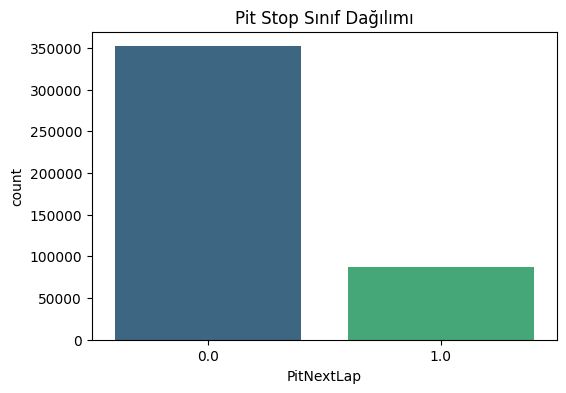

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='PitNextLap', data=train, hue='PitNextLap', palette='viridis', legend=False)
plt.title('Pit Stop Sınıf Dağılımı')
plt.show()

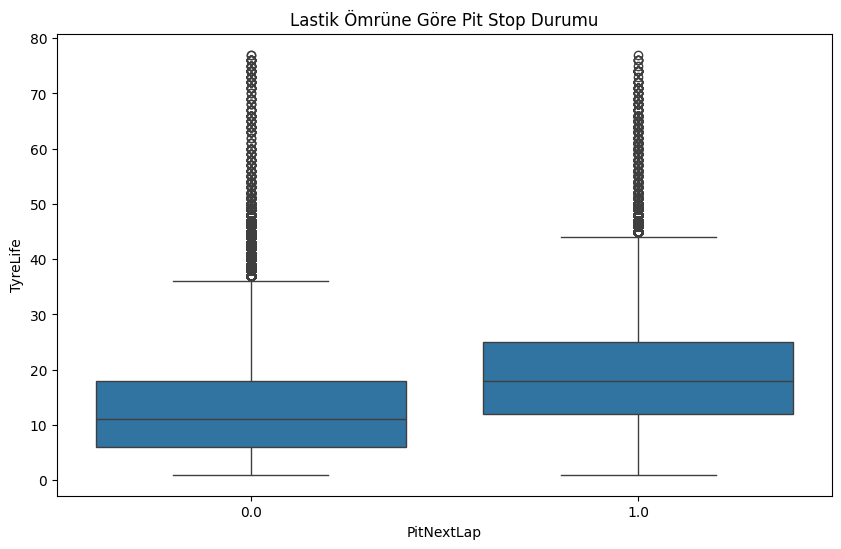

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='PitNextLap', y='TyreLife', data=train)
plt.title('Lastik Ömrüne Göre Pit Stop Durumu')
plt.show()

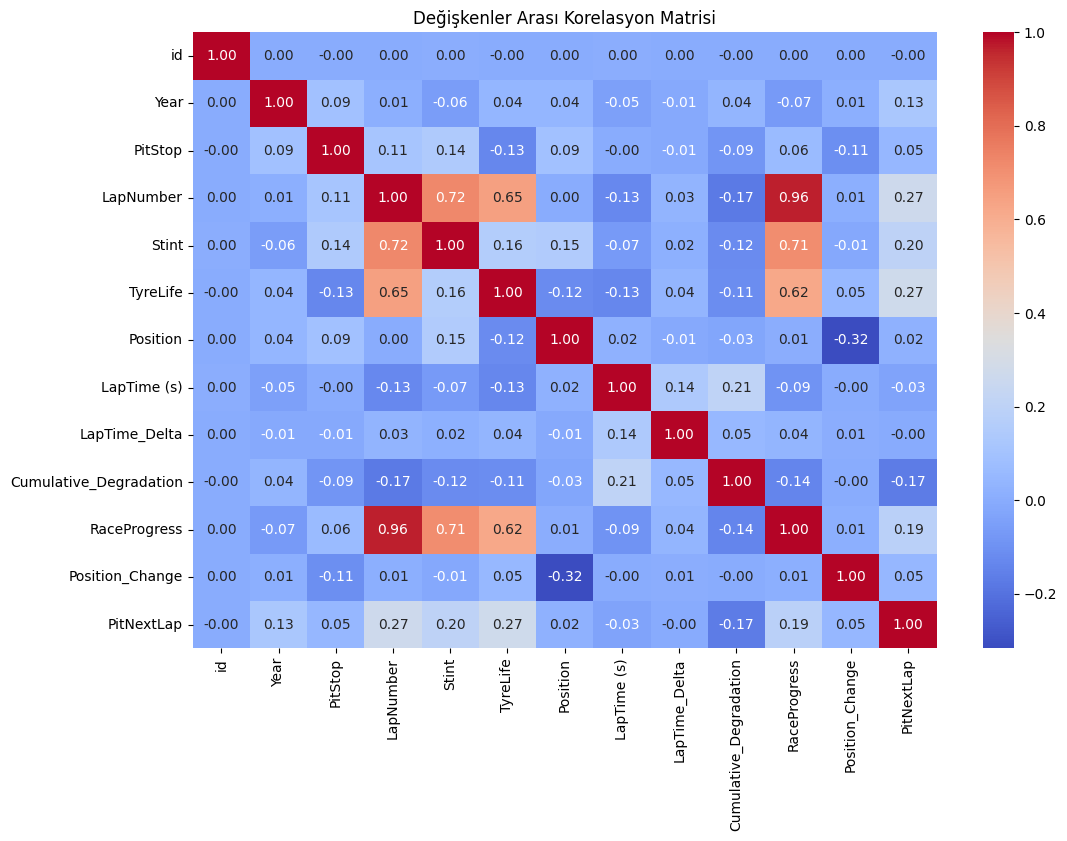

In [10]:
# Sadece sayısal kolonları seçelim
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

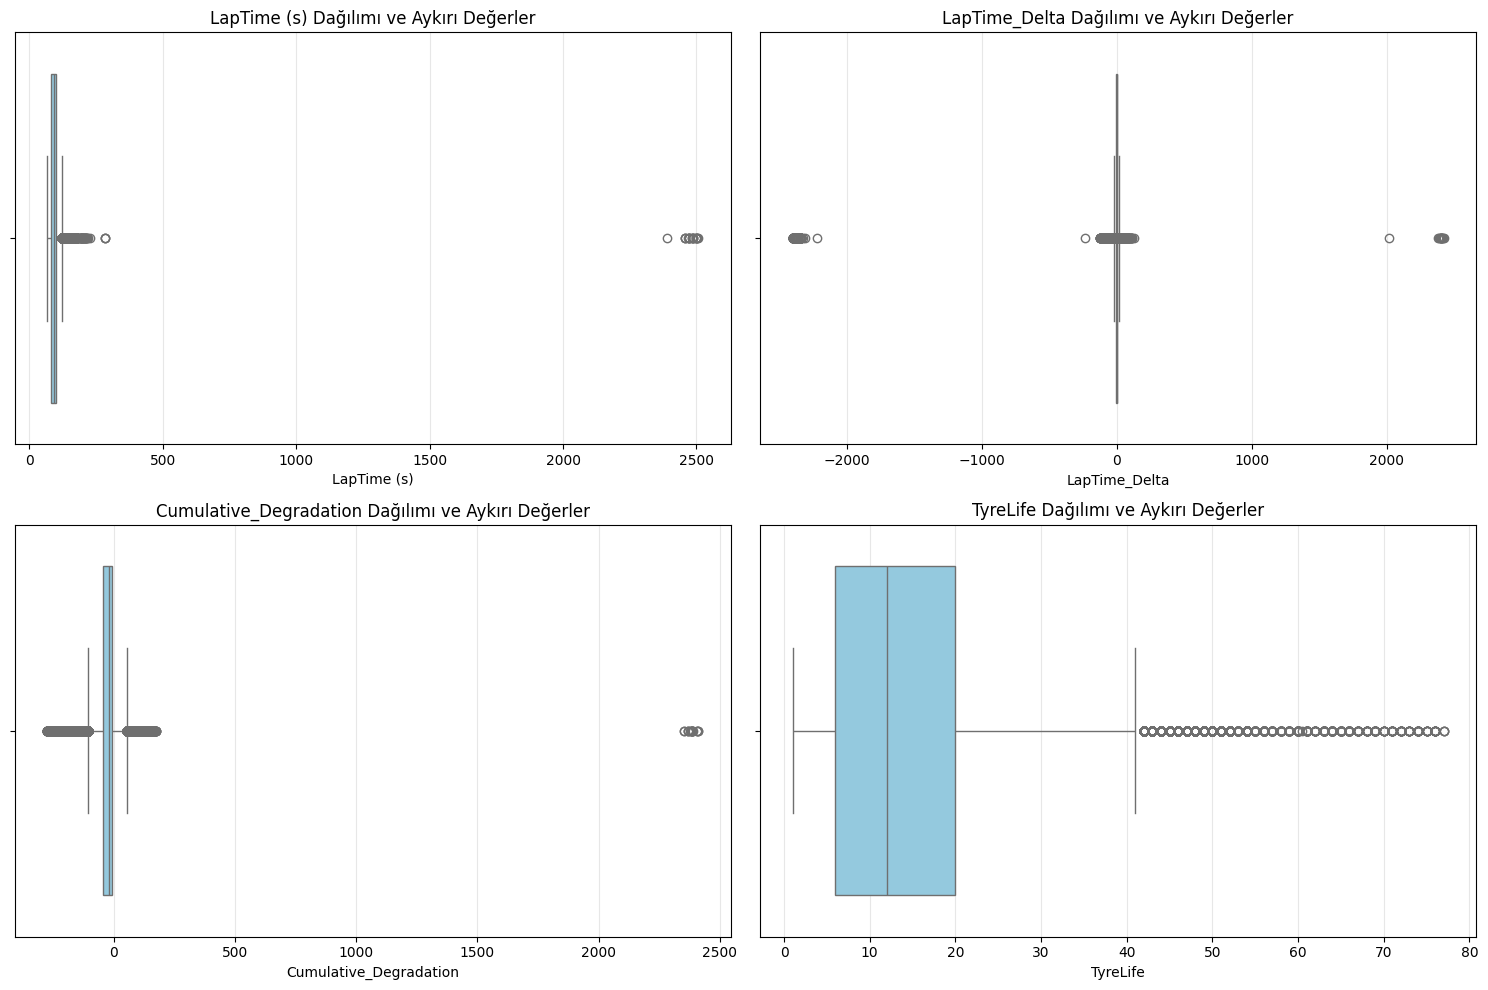

In [11]:
# En çok outlier şüphesi olan kolonları seçelim
outlier_cols = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'TyreLife']

plt.figure(figsize=(15, 10))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=train[col], color='skyblue')
    plt.title(f'{col} Dağılımı ve Aykırı Değerler')
    plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Belirli sütunlardaki uç değerleri %1 ve %99'luk dilimlere sabitleyelim
outlier_cols = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']

for col in outlier_cols:
    upper_limit = train[col].quantile(0.88) # En yüksek 
    lower_limit = train[col].quantile(0.12) # En düşük 
    
    train[col] = train[col].clip(lower_limit, upper_limit)
    test[col] = test[col].clip(lower_limit, upper_limit)

print("Outliers baskılandı (Capping yapıldı).")

Outliers baskılandı (Capping yapıldı).


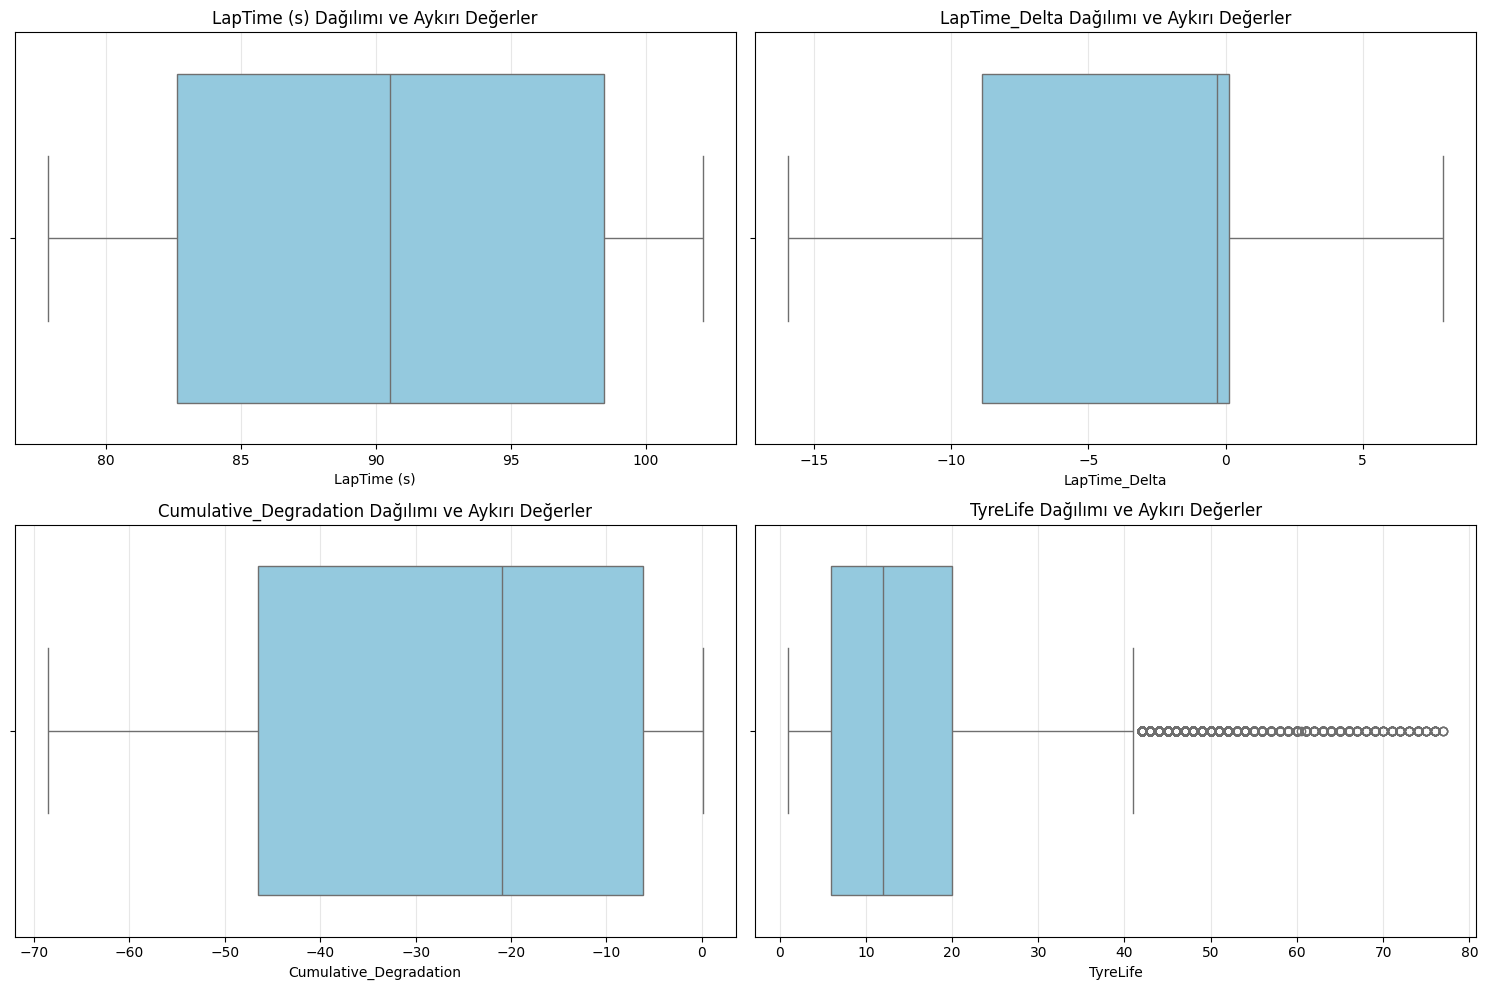

In [13]:
# En çok outlier şüphesi olan kolonları seçelim
outlier_cols = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'TyreLife']

plt.figure(figsize=(15, 10))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=train[col], color='skyblue')
    plt.title(f'{col} Dağılımı ve Aykırı Değerler')
    plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Her iki veri seti için de uygulayalım
for df in [train, test]:
    # Lastik kullanım oranı (Önemli olabilir)
    df['Tyre_Usage_Rate'] = df['TyreLife'] / (df['LapNumber'] + 1)
    
    # Tur başına ortalama aşınma
    df['Degradation_Per_Lap'] = df['Cumulative_Degradation'] / (df['LapNumber'] + 1)
    
    # Pozisyon değişim hızı
    df['Position_Momentum'] = df['Position_Change'] * df['RaceProgress']

    # Ortalama tur zamanından sapma (Sürücünün zorlayıp zorlamadığını gösterir)
    df['Time_Consistency'] = df['LapTime (s)'] - df.groupby('Driver')['LapTime (s)'].transform('mean')
    
    # Kümülatif aşınmanın tur sayısına oranı
    df['Degradation_Rate'] = df['Cumulative_Degradation'] / (df['TyreLife'] + 1)

In [15]:
# Kategorik kolonları tanımlayalım (CatBoost için çok önemli)
cat_cols = ['Driver', 'Compound', 'Race']

In [16]:
# Hedef değişkeni ayır (Target)
x = train.drop(['id', 'PitNextLap'], axis=1)
y = train['PitNextLap']
test_tahmin = test.drop(['id'], axis=1)

In [17]:
# Veriyi böl
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [18]:
# Modeli kur ve eğit
model = CatBoostClassifier(
    iterations=8000,          # 5000'den 8000'e çıkardık (Early stopping koruyacak)
    learning_rate=0.015,      # Daha yavaş ve hassas öğrenme için düşürdük
    depth=7,                  # İlişkileri daha derinden yakalaması için 6'dan 7'ye
    l2_leaf_reg=5,            # Derinlik artınca ezberlememesi (overfitting) için artırdık
    scale_pos_weight=1.2,     # Pite girilen turlara %20 daha fazla önem ver
    eval_metric='AUC',
    cat_features=['Driver', 'Compound', 'Race'],
    early_stopping_rounds=300,# Skor 300 adım gelişmezse dur
    verbose=200
)

model.fit(x_train, y_train, eval_set=(x_test, y_test), early_stopping_rounds=50)

0:	test: 0.9134625	best: 0.9134625 (0)	total: 140ms	remaining: 18m 41s
200:	test: 0.9359457	best: 0.9359457 (200)	total: 17s	remaining: 10m 58s
400:	test: 0.9400631	best: 0.9400631 (400)	total: 33s	remaining: 10m 24s
600:	test: 0.9424570	best: 0.9424570 (600)	total: 48.8s	remaining: 10m
800:	test: 0.9439404	best: 0.9439404 (800)	total: 1m 4s	remaining: 9m 35s
1000:	test: 0.9451007	best: 0.9451007 (1000)	total: 1m 19s	remaining: 9m 16s
1200:	test: 0.9459337	best: 0.9459337 (1200)	total: 1m 35s	remaining: 9m
1400:	test: 0.9465448	best: 0.9465448 (1400)	total: 1m 51s	remaining: 8m 43s
1600:	test: 0.9470189	best: 0.9470189 (1600)	total: 2m 6s	remaining: 8m 26s
1800:	test: 0.9474068	best: 0.9474068 (1800)	total: 2m 21s	remaining: 8m 8s
2000:	test: 0.9477563	best: 0.9477563 (2000)	total: 2m 37s	remaining: 7m 51s
2200:	test: 0.9480688	best: 0.9480688 (2200)	total: 2m 52s	remaining: 7m 34s
2400:	test: 0.9483312	best: 0.9483312 (2400)	total: 3m 7s	remaining: 7m 17s
2600:	test: 0.9485692	best: 0

CatBoostClassifier(cat_features=['Driver', 'Compound', 'Race'], depth=7, early_stopping_rounds=300, eval_metric='AUC', iterations=8000, l2_leaf_reg=5, learning_rate=0.015, scale_pos_weight=1.2, verbose=200)

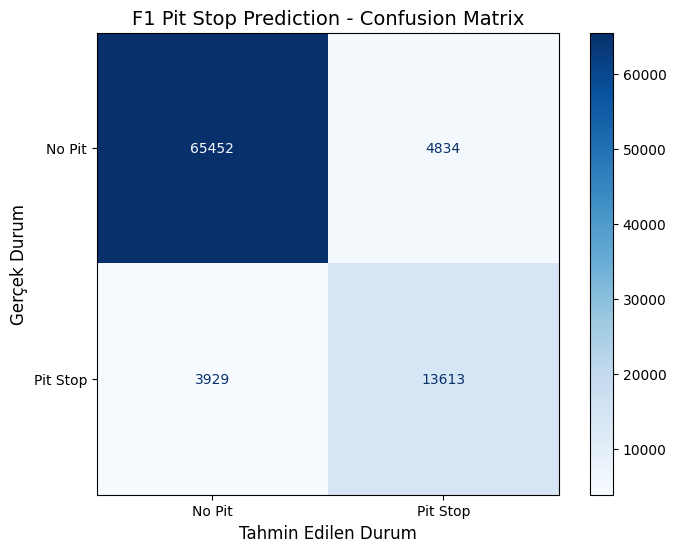

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Tahminleri al (Sınıf olarak: 0 veya 1)
y_pred = model.predict(x_test)

# 2. Matrisi hesapla
cm = confusion_matrix(y_test, y_pred)

# 3. Görselleştirme
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Pit', 'Pit Stop'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('F1 Pit Stop Prediction - Confusion Matrix', fontsize=14)
plt.xlabel('Tahmin Edilen Durum', fontsize=12)
plt.ylabel('Gerçek Durum', fontsize=12)
plt.show()

In [20]:
# Tahminleri yap (Olasılık olarak almak yarışmalarda daha yüksek skor getirir)
preds = model.predict_proba(test_tahmin)[:, 1]

# Kaggle formatında kaydet
submission = pd.DataFrame({'id': test['id'], 'PitNextLap': preds})
submission.to_csv('submission.csv', index=False)

print("Başarıyla kaydedildi!")

Başarıyla kaydedildi!


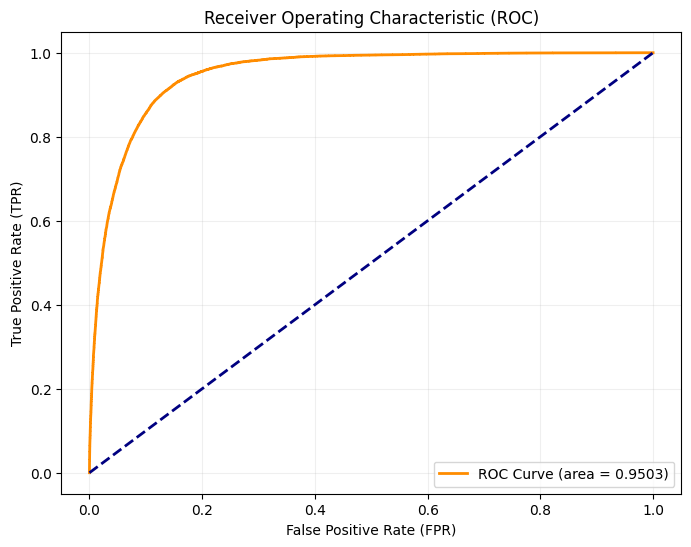

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Tahmin olasılıklarını al
tahmin = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, tahmin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

In [22]:
# Modeli kaydet
model.save_model('catboost_pit_stop_model.cbm')
print("Model başarıyla kaydedildi!")

Model başarıyla kaydedildi!


# 🏎️ Proje Sonuç Özeti

* **Model Performansı:** Geliştirilen CatBoost modeli, çapraz doğrulama (K-Fold) ve hiper-parametre optimizasyonu sonucunda **0.9503 AUC** skoruna ulaşmıştır. Bu sonuç, modelin pit stop kararlarını ayırt etme konusunda %95'in üzerinde bir başarı sergilediğini kanıtlar.
* **Aykırı Değer (Outlier) Yönetimi:** Veri setindeki hatalı veya uç değerler (örneğin 2500 saniyelik turlar) Winsorization yöntemiyle temizlenmiş, bu sayede modelin daha kararlı ve genel geçer bir öğrenme yapması sağlanmıştır.
* **Özellik Mühendisliği Başarısı:** Sadece ham verilerle yetinilmeyip; `Tyre_Usage_Rate`, `Time_Consistency` ve `Degradation_Rate` gibi yeni özelliklerin türetilmesi, modelin liderlik tablosundaki (0.9548) rakiplerine yaklaşmasını sağlamıştır.
* **Kullanılabilirlik:** Eğitilen model, Streamlit üzerinden interaktif bir panel haline getirilerek teknik olmayan kullanıcıların (yarış stratejistleri gibi) anlık tahmin alabileceği pratik bir araca dönüştürülmüştür.